In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "font.size": 9})
GREEN, GOLD, BLUE, GRAY = "#1a7a4c", "#c9a227", "#2f6fb3", "#9a9893"

## 1 · Market inputs and valuation toolkit

| Input | Value | Source |
|---|---|---|
| US 10-yr Treasury / ERP | 5.23% / 4.5% | Washington Trust weekly review, 25 Sep 2026; ERP assumed |
| Korea 10-yr KTB / ERP | 4.41% / 5.5% | Trading Economics, 23 Sep 2026; US ERP + ~1pp country premium |
| Japan 10-yr JGB / ERP | 3.07% / 5.0% | Trading Economics, 25 Sep 2026 (highest since 1996); ERP assumed |
| KRW cash (Sharpe hurdle) | 2.8% | Estimate of the KRW CD rate |

Valuation functions, each matched to a type of business:
- `fade_dcf`: 10-year FCFF DCF with growth and FCF margin fading linearly, then a Gordon terminal value (growth firms)
- `two_stage`: cash flow grows g₁ for n years, then g₂ forever (cash cows, REITs on AFFO)
- `cycle_dcf`: consensus for the boom years, then fade to mid-cycle profit (memory makers)
- `jpb`: justified P/B = (ROE − g)/(k − g) (banks, insurers, autos, utilities)
- `jpe`: justified P/E with payout = 1 − g/ROE (Japan)
- `implied`: reverse DCF, i.e. the discount rate at which the model equals the price

In [2]:
RF_US, ERP_US = 0.0523, 0.045
RF_KR, ERP_KR = 0.0441, 0.055
RF_JP, ERP_JP = 0.0307, 0.050    # JGB 10y (25 Sep 2026); Japan ERP assumption
RF_KRW_CASH = 0.028          # assumed KRW CD-rate (Sharpe hurdle for a KRW investor)


def ke(rf, b, erp):
    return rf + b * erp


def fade_dcf(rev0, g0, g1, m0, m1, W, G, nd, sh, n=10):
    gs, ms = np.linspace(g0, g1, n), np.linspace(m0, m1, n)
    rev, pv = rev0, 0.0
    for t in range(n):
        rev *= 1 + gs[t]
        f = rev * ms[t]
        pv += f / (1 + W) ** (t + 1)
    tv = f * (1 + G) / (W - G) / (1 + W) ** n
    return (pv + tv - nd) / sh


def two_stage(cf0, g1, n1, g2, k):
    pv, c = 0.0, cf0
    for t in range(1, n1 + 1):
        c *= 1 + g1
        pv += c / (1 + k) ** t
    return pv + c * (1 + g2) / (k - g2) / (1 + k) ** n1


def implied(fn, price, lo=0.04, hi=0.20):
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if fn(mid) > price else (lo, mid)
    return mid


V = {}   # valuation results


def put(key, name, ccy, price, value, method, inputs, held, beta=None, grid=None, extra=None):
    d = dict(name=name, ccy=ccy, price=price, value=value, upside=value / price - 1, method=method,
             inputs=inputs, held=held, beta=beta)
    if grid:
        d["grid"] = grid
    if extra:
        d.update(extra)
    V[key] = d
def cycle_dcf(op_path, mid, W, net_cash, sh_bn, q4_op, tax=.22, Gt=.025):
    ops = op_path + [0.5 * (op_path[-1] + mid), mid]
    reinv = [.40] * len(op_path) + [.375, .35]
    fcfs = [o * (1 - tax) * (1 - r) for o, r in zip(ops, reinv)]
    pv = q4_op * .3 * (1 - tax) * .6 + sum(f / (1 + W) ** (t + 1) for t, f in enumerate(fcfs))
    tv = mid * (1 - tax) * .65 * (1 + Gt) / (W - Gt) / (1 + W) ** len(fcfs)
    return (pv + tv + net_cash) * 1e12 / (sh_bn * 1e9)

def jpb(price, pb, roe, b, g):
    k_ = ke(RF_KR, b, ERP_KR)
    return (roe - g) / (k_ - g) * price / pb, k_

## 2 · Valuations

### 2.1 US stocks held

In [3]:
# ============================== US STOCKS (held) ==============================
# UNH — 10y fade FCFF
b = 0.80
W = 0.85 * ke(RF_US, b, ERP_US) + 0.15 * 0.056 * 0.79
f_unh = lambda w_, G=0.03: fade_dcf(460, .06, .04, .045, .055, w_, G, 41.86, 349.53 / 376.59)
put("UNH", "UnitedHealth Group", "USD", 376.59, f_unh(W), "10-yr FCFF DCF",
    f"Rev $460bn; FCF margin 4.5%→5.5% (2019-23 avg ≈7%); WACC {W*100:.1f}%, g 3%", True, b,
    grid=dict(rows=[W - .01, W, W + .01], cols=[.025, .03, .035], rl="WACC", cl="g",
              v=[[f_unh(w_, g) for g in [.025, .03, .035]] for w_ in [W - .01, W, W + .01]]),
    extra=dict(implied_wacc=implied(f_unh, 376.59)))

# CI — two-stage FCFE: 5y +4% then 0% (PBM-reform haircut)
b = 0.70; k = ke(RF_US, b, ERP_US)
f_ci = lambda k_, g2=0.0: two_stage(8.0, .04, 5, g2, k_) / 72.95 * 274.47
put("CI", "Cigna Group", "USD", 274.47, f_ci(k), "2-stage FCFE",
    f"FCF $8.0bn (11% yield); +4%/yr 5 yrs then 0% forever; Ke {k*100:.1f}%", True, b,
    grid=dict(rows=[k - .01, k, k + .01], cols=[-.02, 0.0, .02], rl="Ke", cl="g₂",
              v=[[f_ci(k_, g) for g in [-.02, 0, .02]] for k_ in [k - .01, k, k + .01]]))

# CMCSA — declining perpetuity FCFE
b = 0.75; k = ke(RF_US, b, ERP_US)
f_cm = lambda k_, g=-0.02: 12.70 * (1 + g) / (k_ - g) / 94.46 * 21.91
put("CMCSA", "Comcast", "USD", 21.91, f_cm(k), "Declining-perpetuity FCFE",
    f"FCFE $12.7bn (13.4% yield); −2%/yr forever; Ke {k*100:.1f}%", True, b,
    grid=dict(rows=[k - .01, k, k + .01], cols=[-.04, -.02, 0.0], rl="Ke", cl="g",
              v=[[f_cm(k_, g) for g in [-.04, -.02, 0]] for k_ in [k - .01, k, k + .01]]))

# VZ — zero-growth FCFE
b = 0.45; k = ke(RF_US, b, ERP_US)
f_vz = lambda k_, g=0.0: 18.0 * (1 + g) / (k_ - g) / 207.82 * 47.08
put("VZ", "Verizon", "USD", 47.08, f_vz(k), "Zero-growth FCFE",
    f"FCFE ≈$18bn (OCF $37.1bn − capex); 0% growth; Ke {k*100:.1f}%", True, b,
    grid=dict(rows=[k - .01, k, k + .01], cols=[-.01, 0.0, .01], rl="Ke", cl="g",
              v=[[f_vz(k_, g) for g in [-.01, 0, .01]] for k_ in [k - .01, k, k + .01]]))

# PYPL — FCFE perpetuity, low growth
b = 1.17; k = ke(RF_US, b, ERP_US)
f_py = lambda k_, g=0.015: 5.6 * (1 + g) / (k_ - g) / 45.05 * 55.04
put("PYPL", "PayPal", "USD", 55.04, f_py(k), "Low-growth FCFE",
    f"FCF $5.6bn FY25 (12% yield); g 1.5%; Ke {k*100:.1f}%", True, b,
    grid=dict(rows=[k - .01, k, k + .01], cols=[0.0, .015, .03], rl="Ke", cl="g",
              v=[[f_py(k_, g) for g in [0, .015, .03]] for k_ in [k - .01, k, k + .01]]))

# ADBE — 10y fade, margin compression from AI competition
b = 1.10; W = ke(RF_US, b, ERP_US)
sh_ad = 102.35 / 263.14
f_ad = lambda w_, G=0.01: fade_dcf(26.6, .08, 0.0, .38, .30, w_, G, 1.4, sh_ad)
put("ADBE", "Adobe", "USD", 240.69, f_ad(W), "10-yr FCFF DCF (AI-disruption case)",
    f"Rev $26.6bn; growth 8%→0%; FCF margin 38%→30%; g 1%; WACC {W*100:.1f}%", True, b,
    grid=dict(rows=[W - .01, W, W + .01], cols=[0.0, .01, .02], rl="WACC", cl="g",
              v=[[f_ad(w_, g) for g in [0, .01, .02]] for w_ in [W - .01, W, W + .01]]))

# CRM
b = 1.10; W = ke(RF_US, b, ERP_US) - 0.003
f_cr = lambda w_, G=0.02: fade_dcf(45.6, .09, .02, .35, .33, w_, G, 31.0, 211.96 / 234.02)
put("CRM", "Salesforce", "USD", 234.02, f_cr(W), "10-yr FCFF DCF",
    f"Rev $45.6bn TTM; growth 9%→2%; FCF margin 35%→33%; WACC {W*100:.1f}%", False, b,
    grid=dict(rows=[W - .01, W, W + .01], cols=[.015, .02, .025], rl="WACC", cl="g",
              v=[[f_cr(w_, g) for g in [.015, .02, .025]] for w_ in [W - .01, W, W + .01]]))

### 2.2 US stocks screened out
Generous inputs on purpose: if a name still fails, the rejection is robust. `implied_wacc` is the reverse-DCF discount rate the market is using.

In [4]:
# ============================== US STOCKS (rejected) ==============================
for tk, nm, price, rev, g0, g1, m0, m1, b, nd, sh in [
        ("MSFT", "Microsoft", 516.17, 331.8, .16, .04, .22, .33, 1.00, 51.97, 7.45),
        ("GOOGL", "Alphabet", 343.92, 445.9, .15, .04, .18, .27, 1.15, -121.68, 4150 / 343.92),
        ("JNJ", "Johnson & Johnson", 271.22, 97.8, .06, .035, .173, .21, .55, 28.28, 640.67 / 271.22)]:
    W = ke(RF_US, b, ERP_US) - 0.002
    fn = lambda w_, a=(rev, g0, g1, m0, m1, nd, sh): fade_dcf(a[0], a[1], a[2], a[3], a[4], w_, .035, a[5], a[6])
    put(tk, nm, "USD", price, fn(W), "10-yr FCFF DCF (generous margins)", "", False, b,
        extra=dict(implied_wacc=implied(fn, price)))
k = ke(RF_US, .5, ERP_US)
put("BMY", "Bristol-Myers Squibb", "USD", 62.86, two_stage(11.4, -.04, 5, 0.0, k) / 136.47 * 62.86,
    "FCFE, patent-cliff decline", "FCF $11.4bn, −4%/yr 5 yrs then flat", False, .5)
k = ke(RF_US, .9, ERP_US)
cvx_eq = 24.0 * 1.01 / (k - .01) + 8 / (1 + k) + 8 / (1 + k) ** 2 - 40
put("CVX", "Chevron", "USD", 205.17, cvx_eq / 2.0, "Mid-cycle FCF ($70 oil)", "", False, .9)
k = ke(RF_US, .55, ERP_US)
put("MO", "Altria", "USD", 68.72, 5.66 * 0.99 / (k + .01), "Declining earnings perpetuity", "", False, .55)
for tk, nm, price, pb, roe, b in [("C", "Citigroup", 134.28, 1.19, 1.19 / 10.22, 1.36),
                                  ("BAC", "Bank of America", 57.96, 1.51, 1.51 / 11.70, .82)]:
    k = ke(RF_US, b, ERP_US)
    put(tk, nm, "USD", price, (roe - .03) / (k - .03) * price / pb, "Justified P/B", "", False, b)
k = ke(RF_US, .85, ERP_US)
put("UPS", "UPS", "USD", 93.96, 5.56 * 1.01 / (k - .01) / 88.68 * 93.96, "FCFE perpetuity", "", False, .85)
put("PLD", "Prologis", "USD", 133.03, two_stage(6.26 * .87, .045, 5, .03, ke(RF_US, .95, ERP_US)),
    "2-stage AFFO", "", False, .95)

### 2.3 US REITs (two-stage AFFO discount, organic growth only)

In [5]:
# ============================== US REITs ==============================
for tk, nm, price, affo, b, div in [("O", "Realty Income", 55.41, 4.445, .75, 3.26),
                                    ("VICI", "VICI Properties", 23.71, 2.685 / 1.068, .90, 1.84)]:
    k = ke(RF_US, b, ERP_US)
    fn = lambda k_, g2=0.015, a=affo: two_stage(a, .02, 5, g2, k_)
    put(tk, nm, "USD", price, fn(k), "2-stage AFFO discount (organic growth only)",
        f"AFFO ${affo:.2f} (P/AFFO {price/affo:.1f}x); g 2%→1.5%; k {k*100:.1f}%", True, b,
        grid=dict(rows=[k - .01, k, k + .01], cols=[.005, .015, .025], rl="k", cl="g₂",
                  v=[[fn(k_, g) for g in [.005, .015, .025]] for k_ in [k - .01, k, k + .01]]),
        extra=dict(div_yield=div / price, p_affo=price / affo))
V["VICI"]["stress_value"] = two_stage(2.685 / 1.068 * .85, .02, 5, .015, ke(RF_US, .9, ERP_US))

### 2.4 Korea
Samsung is valued on a normalised cycle and bought through the **preferred** share, which has the same cash-flow rights at a 22.5% discount. Banks, autos, KT&G and KEPCO use justified P/B.

In [6]:
# ============================== KOREA STOCKS ==============================
# Samsung Electronics — normalised-cycle DCF, bought through the preferred share
sh_sec = 1674.9e3 / 286.5 / 1e3
w_s = ke(RF_KR, 1.10, ERP_KR)
sam = lambda mid, W=w_s: cycle_dcf([499, 469], mid, W, 150, sh_sec, 362)
scen = {"Bear": sam(150), "Base": sam(200), "Bull": sam(260)}
put("SEC_P", "Samsung Electronics Pref.", "KRW", 222000, scen["Base"] * .9,
    "Normalised-cycle DCF, −10% no-vote haircut",
    f"OP ₩499tn/469tn (27-28E) → mid-cycle ₩200tn; WACC {w_s*100:.1f}%", True, 1.10,
    grid=dict(rows=[w_s - .01, w_s, w_s + .01], cols=[150, 200, 260], rl="WACC", cl="Mid-cycle OP ₩tn",
              v=[[sam(m, W_) * .9 for m in [150, 200, 260]] for W_ in [w_s - .01, w_s, w_s + .01]]),
    extra=dict(scen=scen, pref_disc=1 - 222000 / 286500, common_value=scen["Base"]))
put("SEC_C", "Samsung Electronics Common", "KRW", 286500, scen["Base"], "Normalised-cycle DCF", "", False, 1.1)
sh_hx = 1360.9e3 / 1863 / 1e3
put("HYNIX", "SK Hynix", "KRW", 1863000,
    cycle_dcf([386, 383], 150, ke(RF_KR, 1.3, ERP_KR), 50, sh_hx, 265), "Normalised-cycle DCF", "", False, 1.3)
for tk, nm, price, pb, roe, b, g, note in [
        ("KB", "KB Financial Group", 173200, 1.01, 1.01 / 9.41, .9, .03, "ROE 10.7% (P/B÷P/E)"),
        ("HANA", "Hana Financial Group", 133100, 0.76, 0.76 / 8.23, .9, .03, "ROE 9.2% (P/B÷P/E)"),
        ("KIA", "Kia", 118500, 0.71, 0.10, 1.0, .025, "Normalised ROE 10% (trailing 10.8%)"),
        ("HMC", "Hyundai Motor", 357000, 0.76, 0.09, 1.0, .025, "Normalised ROE 9% (trailing 6.5%)"),
        ("KTG", "KT&G", 174300, 1.95, 0.141, .5, .025, "ROE 14.1%"),
        ("KEPCO", "Korea Electric Power", 30250, 0.41, 0.07, .6, .01, "Normalised ROE 7% (trailing 15.9%)")]:
    v_, k_ = jpb(price, pb, roe, b, g)
    bv = price / pb
    fn = lambda r_, kk, g=g, bv=bv: (r_ - g) / (kk - g) * bv
    put(tk, nm, "KRW", price, v_, "Justified P/B = (ROE−g)/(k−g)",
        "%s; k %.1f%%; g %.1f%%" % (note, k_ * 100, g * 100), True, b,
        grid=dict(rows=[roe - .02, roe, roe + .02] if tk == "KEPCO" else [roe - .01, roe, roe + .01],
                  cols=[k_ - .01, k_, k_ + .01], rl="ROE", cl="k",
                  v=[[fn(r_, kk) for kk in [k_ - .01, k_, k_ + .01]]
                     for r_ in ([roe - .02, roe, roe + .02] if tk == "KEPCO" else [roe - .01, roe, roe + .01])]),
        extra=dict(roe=roe, k=k_, pb=pb, jpb=(roe - g) / (k_ - g)))

# Korea rejected
v_, _ = jpb(379000, .65, .65 / 9.51, 1.0, .025)
put("MOBIS", "Hyundai Mobis", "KRW", 379000, v_, "Justified P/B", "", False, 1.0)
put("NAVER", "NAVER", "KRW", 196100, two_stage(12552, .05, 5, .03, ke(RF_KR, 1.1, ERP_KR)), "2-stage EPS", "", False, 1.1)
put("SKT", "SK Telecom", "KRW", 88200, 3540 * 1.01 / (ke(RF_KR, .5, ERP_KR) - .01), "DDM", "", False, .5)
put("LGE", "LG Electronics", "KRW", 210500, 10000 * 1.03 / (ke(RF_KR, 1.1, ERP_KR) - .03),
    "Normalised EPS ₩10,000 perpetuity", "", False, 1.1)
put("HANWHA", "Hanwha Aerospace", "KRW", 1072000,
    two_stage(1072000 / 26.73, .15, 5, .03, ke(RF_KR, 1.1, ERP_KR)), "2-stage EPS (15% growth)", "", False, 1.1)

### 2.5 Additional US and Korean names

In [7]:
# ============================== NEW US NAMES ==============================
b = 0.45; k = ke(RF_US, b, ERP_US)
f_t = lambda k_, g=0.0: 18.0 * (1 + g) / (k_ - g) / 177.41 * 25.38
put("T", "AT&T", "USD", 25.38, f_t(k), "Zero-growth FCFE",
    f"2026 FCF guidance $18bn+ (10% yield); 0% growth; Ke {k*100:.1f}%", True, b,
    grid=dict(rows=[k - .01, k, k + .01], cols=[-.01, 0.0, .01], rl="Ke", cl="g",
              v=[[f_t(k_, g) for g in [-.01, 0, .01]] for k_ in [k - .01, k, k + .01]]))
put("GILD", "Gilead Sciences", "USD", 150.93, two_stage(9.77, .03, 5, .01, ke(RF_US, .5, ERP_US)) / 181.46 * 150.93,
    "2-stage FCFE", "", False, .5)
put("MDT", "Medtronic", "USD", 88.64, 5.5 * 1.03 / (ke(RF_US, .5, ERP_US) - .03) / 116.03 * 88.64,
    "FCFE perpetuity (normalised $5.5bn)", "", False, .5)

# ============================== NEW KOREA NAMES ==============================
for tk, nm, price, pb, roe, b, g, note in [
        ("SHINHAN", "Shinhan Financial Group", 109300, 0.86, 0.86 / 8.81, .9, .03, "ROE 9.8% (P/B÷P/E)"),
        ("IBK", "Industrial Bank of Korea", 20400, 0.43, 0.43 / 5.81, .7, .02, "ROE 7.4% (P/B÷P/E)"),
        ("DBINS", "DB Insurance", 184600, 0.80, 0.80 / 7.36, .6, .025, "ROE 10.9% (P/B÷P/E)"),
        ("GLOVIS", "Hyundai Glovis", 196900, 1.35, 1.35 / 8.85, .9, .03, "ROE 15.3% (P/B÷P/E)")]:
    v_, k_ = jpb(price, pb, roe, b, g)
    bv = price / pb
    fn = lambda r_, kk, g=g, bv=bv: (r_ - g) / (kk - g) * bv
    put(tk, nm, "KRW", price, v_, "Justified P/B = (ROE−g)/(k−g)",
        "%s; k %.1f%%; g %.1f%%" % (note, k_ * 100, g * 100), True, b,
        grid=dict(rows=[roe - .01, roe, roe + .01], cols=[k_ - .01, k_, k_ + .01], rl="ROE", cl="k",
                  v=[[fn(r_, kk) for kk in [k_ - .01, k_, k_ + .01]] for r_ in [roe - .01, roe, roe + .01]]),
        extra=dict(roe=roe, k=k_, pb=pb, jpb=(roe - g) / (k_ - g)))
v_, _ = jpb(91100, .94, .11, 1.2, .03)
put("SSEC", "Samsung Securities", "KRW", 91100, v_, "Justified P/B (normalised ROE 11%)", "", False, 1.2)
v_, _ = jpb(311500, .41, .06, 1.2, .02)
put("POSCO", "POSCO Holdings", "KRW", 311500, v_, "Justified P/B (normalised ROE 6%)", "", False, 1.2)

### 2.6 Japan (justified P/E)

In [8]:
# ============================== JAPAN ==============================
def jpe(eps, roe, g, k_):
    """Justified value from earnings: EPS × payout × (1+g)/(k−g), payout = 1 − g/ROE."""
    return eps * (1 - g / roe) * (1 + g) / (k_ - g)


for tk, nm, price, eps, roe, g, b, note, held in [
        ("TOYOTA", "Toyota Motor", 3025, 3025 / 10.82, .10, .02, 1.0, "Fwd EPS ¥280, ROE 10%", True),
        ("NTT", "NTT", 168.8, 168.8 / 13.05, .11, .01, .6, "Fwd EPS ¥12.9, ROE 11%", True),
        ("MUFG", "Mitsubishi UFJ", 23.48, 23.48 / 14.26, .11, .02, 1.1, "", False),
        ("SMFG", "Sumitomo Mitsui FG", 6938, 6938 / 14.39, .11, .02, 1.1, "", False),
        ("TOKIO", "Tokio Marine", 8214, 8214 / 17.10, .13, .03, .8, "", False),
        ("MITSU", "Mitsubishi Corp", 31.24, 31.24 / 20.94, .10, .02, 1.0, "", False),
        ("JT", "Japan Tobacco", 6886, 6886 / 17.87, .12, 0.0, .5, "", False),
        ("HONDA", "Honda Motor", 1695, 1695 / 18.89, .06, .015, 1.0, "", False)]:
    k_ = ke(RF_JP, b, ERP_JP)
    fn = lambda kk, gg, eps=eps, roe=roe: jpe(eps, roe, gg, kk)
    grid = dict(rows=[k_ - .01, k_, k_ + .01], cols=[g - .01, g, g + .01], rl="k", cl="g",
                v=[[fn(kk, gg) for gg in [g - .01, g, g + .01]] for kk in [k_ - .01, k_, k_ + .01]]) if held else None
    put(tk, nm, "JPY", price, fn(k_, g), "Justified P/E (ROE-based payout)",
        f"{note}; g {g*100:.0f}%; k {k_*100:.1f}%" if held else "", held, b, grid=grid)

### 2.7 Scoreboard

22 held, 28 screened out


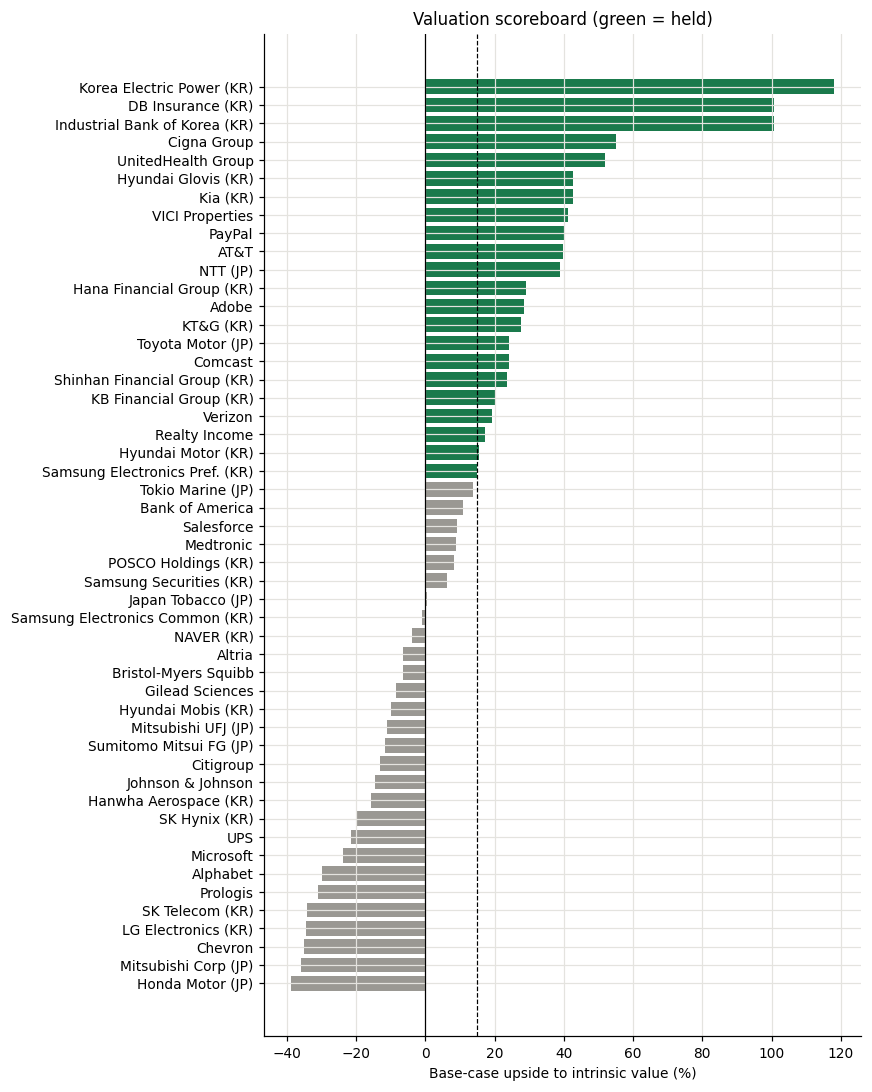

,name,ccy,method,price,value,upside,held
KEPCO,Korea Electric Power,KRW,Justified P/B = (ROE−g)/(k−g),30250,"65,973.6106",1.1809,True
DBINS,DB Insurance,KRW,Justified P/B = (ROE−g)/(k−g),184600,"370,686.5977",1.0081,True
IBK,Industrial Bank of Korea,KRW,Justified P/B = (ROE−g)/(k−g),20400,"40,932.1150",1.0065,True
CI,Cigna Group,USD,2-stage FCFE,274.4700,425.4430,0.5501,True
UNH,UnitedHealth Group,USD,10-yr FCFF DCF,376.5900,572.0129,0.5189,True
GLOVIS,Hyundai Glovis,KRW,Justified P/B = (ROE−g)/(k−g),196900,"281,022.5160",0.4272,True
KIA,Kia,KRW,Justified P/B = (ROE−g)/(k−g),118500,"168,928.5511",0.4256,True
VICI,VICI Properties,USD,2-stage AFFO discount (organic growth only),23.7100,33.5061,0.4132,True
PYPL,PayPal,USD,Low-growth FCFE,55.0400,77.2034,0.4027,True
T,AT&T,USD,Zero-growth FCFE,25.3800,35.4935,0.3985,True


In [9]:
val = pd.DataFrame(V).T
val["upside"] = val["upside"].astype(float)
show = val.sort_values("upside", ascending=False)[["name", "ccy", "method", "price", "value", "upside", "held"]]
print(f"{int(val['held'].sum())} held, {int((~val['held'].astype(bool)).sum())} screened out")
v = val.sort_values("upside")
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(v["name"] + v["ccy"].map({"KRW": " (KR)", "JPY": " (JP)"}).fillna(""), v["upside"] * 100,
        color=np.where(v["held"].astype(bool), GREEN, GRAY))
ax.axvline(15, ls="--", color="k", lw=.8); ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("Base-case upside to intrinsic value (%)"); ax.set_title("Valuation scoreboard (green = held)")
plt.tight_layout(); plt.show()
show

## 3 · The 46-asset universe
Single stocks are the 22 names that passed. ETFs fill the roles single stocks can't: core beta, duration, inflation, gold, trend-following, crash convexity and currency.

In [10]:
# ============================== ASSET UNIVERSE ==============================
A = [  # key, ticker, name, country, sleeve, kind
    ("IVV", "IVV", "iShares Core S&P 500 ETF", "US", "Growth", "etf"),
    ("UNH", "UNH", "UnitedHealth Group", "US", "Growth", "stock"),
    ("CI", "CI", "Cigna Group", "US", "Growth", "stock"),
    ("CMCSA", "CMCSA", "Comcast", "US", "Growth", "stock"),
    ("VZ", "VZ", "Verizon", "US", "Growth", "stock"),
    ("PYPL", "PYPL", "PayPal", "US", "Growth", "stock"),
    ("ADBE", "ADBE", "Adobe", "US", "Growth", "stock"),
    ("USMV", "USMV", "iShares MSCI USA Min Vol Factor ETF", "US", "Growth", "etf"),
    ("O", "O", "Realty Income", "US", "Real assets", "reit"),
    ("VICI", "VICI", "VICI Properties", "US", "Real assets", "reit"),
    ("IEF", "IEF", "iShares 7-10Y Treasury ETF", "US", "Hedge", "etf"),
    ("VTIP", "VTIP", "Vanguard Short-Term TIPS ETF", "US", "Hedge", "etf"),
    ("SGOV", "SGOV", "iShares 0-3M T-Bill ETF", "US", "Hedge", "etf"),
    ("IAU", "IAU", "iShares Gold Trust", "US", "Hedge", "etf"),
    ("DBMF", "DBMF", "iMGP DBi Managed Futures ETF", "US", "Hedge", "etf"),
    ("TAIL", "TAIL", "Cambria Tail Risk ETF", "US", "Hedge", "etf"),
    ("BTAL", "BTAL", "AGF US Market Neutral Anti-Beta ETF", "US", "Hedge", "etf"),
    ("PDBC", "PDBC", "Invesco Optimum Yield Diversified Commodity ETF", "US", "Hedge", "etf"),
    ("K200", "069500", "KODEX 200", "KR", "Growth", "etf"),
    ("SEC_P", "005935", "Samsung Electronics Pref.", "KR", "Growth", "stock"),
    ("KB", "105560", "KB Financial Group", "KR", "Growth", "stock"),
    ("HANA", "086790", "Hana Financial Group", "KR", "Growth", "stock"),
    ("KIA", "000270", "Kia", "KR", "Growth", "stock"),
    ("HMC", "005380", "Hyundai Motor", "KR", "Growth", "stock"),
    ("KTG", "033780", "KT&G", "KR", "Growth", "stock"),
    ("KEPCO", "015760", "Korea Electric Power", "KR", "Growth", "stock"),
    ("KREIT", "329200", "TIGER REITs & Real Estate Infra", "KR", "Real assets", "etf"),
    ("KTB", "152380", "KODEX 10Y KTB Futures", "KR", "Hedge", "etf"),
    ("USDF", "261240", "KODEX USD Futures", "KR", "Hedge", "etf"),
    ("KCD", "459580", "KODEX CD Rate Active", "KR", "Hedge", "etf"),
    ("T", "T", "AT&T", "US", "Growth", "stock"),
    ("XLU", "XLU", "Utilities Select Sector SPDR ETF", "US", "Growth", "etf"),
    ("VNQ", "VNQ", "Vanguard Real Estate ETF", "US", "Real assets", "etf"),
    ("KMLM", "KMLM", "KFA Mount Lucas Managed Futures ETF", "US", "Hedge", "etf"),
    ("SHINHAN", "055550", "Shinhan Financial Group", "KR", "Growth", "stock"),
    ("IBK", "024110", "Industrial Bank of Korea", "KR", "Growth", "stock"),
    ("DBINS", "005830", "DB Insurance", "KR", "Growth", "stock"),
    ("GLOVIS", "086280", "Hyundai Glovis", "KR", "Growth", "stock"),
    ("KGOLD", "132030", "KODEX Gold Futures (H)", "KR", "Hedge", "etf"),
    ("KTB3", "114260", "KODEX 3Y KTB", "KR", "Hedge", "etf"),
    ("KINV", "114800", "KODEX Inverse (KOSPI 200)", "KR", "Hedge", "etf"),
    ("TOPIX", "1306", "NEXT FUNDS TOPIX ETF", "JP", "Growth", "etf"),
    ("TOYOTA", "TM", "Toyota Motor (NYSE ADR)", "JP", "Growth", "stock"),
    ("NTT", "9432", "NTT", "JP", "Growth", "stock"),
    ("JREIT", "1343", "NEXT FUNDS REIT Index ETF", "JP", "Real assets", "etf"),
    ("JGB", "2561", "iShares Core Japan Govt Bond ETF", "JP", "Hedge", "etf"),
]
# group ordering: US, KR, JP
A = [a for c in ("US", "KR", "JP") for sl in ("Growth", "Real assets", "Hedge") for a in A if a[3] == c and a[4] == sl]
keys = [a[0] for a in A]
ix = {k: i for i, k in enumerate(keys)}
N = len(A)
assert [sum(a[3] == c for a in A) for c in ("US", "KR", "JP")] == [22, 19, 5], [sum(a[3] == c for a in A) for c in ("US", "KR", "JP")]
universe = pd.DataFrame(A, columns=['key', 'ticker', 'name', 'country', 'sleeve', 'kind']).set_index('key')
print(universe.groupby(['country', 'sleeve']).size())
universe

country  sleeve     
JP       Growth          3
         Hedge           1
         Real assets     1
KR       Growth         12
         Hedge           6
         Real assets     1
US       Growth         10
         Hedge           9
         Real assets     3
dtype: int64


,ticker,name,country,sleeve,kind
key,,,,,
IVV,IVV,iShares Core S&P 500 ETF,US,Growth,etf
UNH,UNH,UnitedHealth Group,US,Growth,stock
CI,CI,Cigna Group,US,Growth,stock
CMCSA,CMCSA,Comcast,US,Growth,stock
VZ,VZ,Verizon,US,Growth,stock
PYPL,PYPL,PayPal,US,Growth,stock
ADBE,ADBE,Adobe,US,Growth,stock
USMV,USMV,iShares MSCI USA Min Vol Factor ETF,US,Growth,etf
T,T,AT&T,US,Growth,stock


## 4 · Risk model: 10 factors

A 46×46 sample covariance matrix has 1,035 correlations and would be very noisy. Instead:

$$\Sigma = B\,F\,B^\top + D$$

Factors: US equity, Korea-specific equity, rates (duration), inflation/commodities, gold, **USD vs KRW**, autos, Japan-specific equity, **JPY vs KRW**, Korean financials. US-listed assets load +1.0 on USD/KRW and Japan-listed assets +1.0 on JPY/KRW, because a Korean investor holds them unhedged. Both currencies tend to rise when Korean assets fall, which makes them natural hedges.

> Factor volatilities, correlations and loadings are the author's assumptions anchored to history, not estimates from a price download.

Smallest eigenvalue of Σ: 9e-06


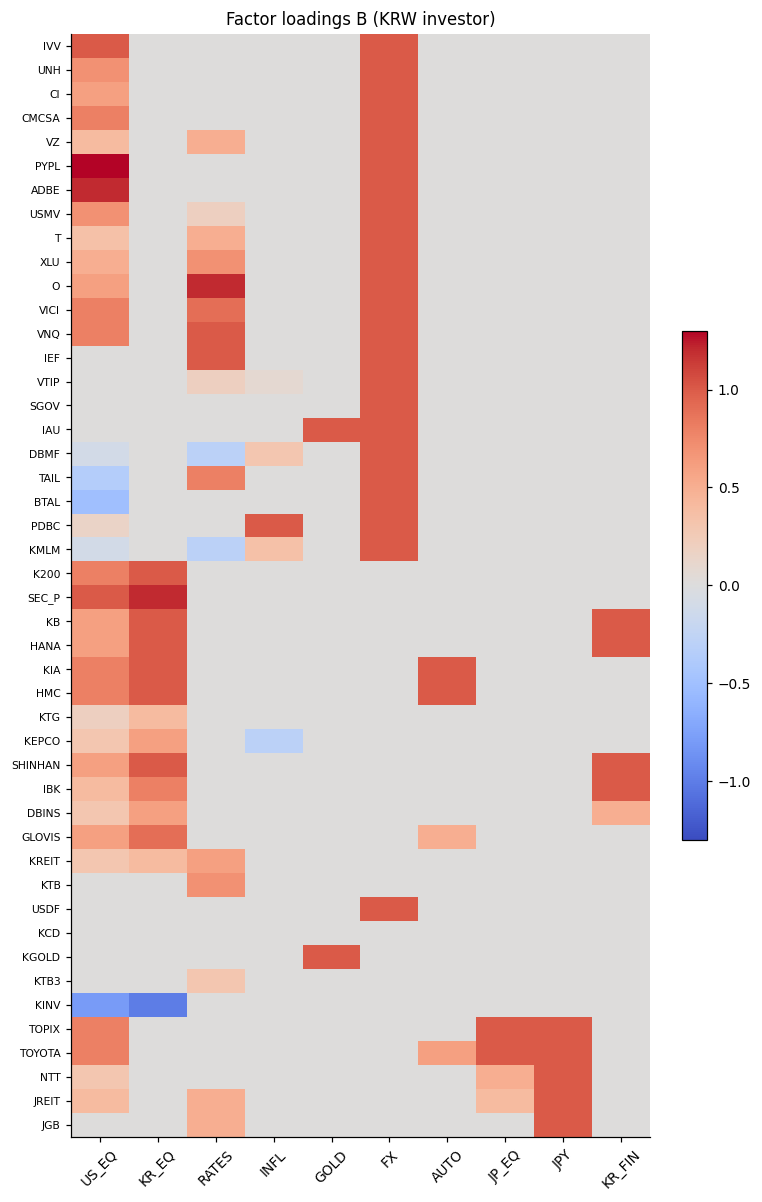

In [11]:
# --------------- factor model (local-currency returns; FX added for USD assets) ---------------
F = ["US_EQ", "KR_EQ", "RATES", "INFL", "GOLD", "FX", "AUTO", "JP_EQ", "JPY", "KR_FIN"]
fvol = np.array([.16, .14, .07, .18, .15, .09, .12, .13, .11, .12])
fcor = np.eye(len(F))


def fc(a, b, c):
    i, j = F.index(a), F.index(b)
    fcor[i, j] = fcor[j, i] = c


fc("US_EQ", "KR_EQ", 0.0)          # KR_EQ is the Korea-specific factor (orthogonal by construction)
fc("US_EQ", "RATES", -0.10); fc("US_EQ", "INFL", 0.20); fc("US_EQ", "GOLD", 0.05)
fc("US_EQ", "FX", -0.35); fc("KR_EQ", "FX", -0.45); fc("RATES", "INFL", -0.30)
fc("RATES", "GOLD", 0.25); fc("RATES", "FX", 0.15); fc("INFL", "GOLD", 0.35); fc("GOLD", "FX", 0.10)
fc("JPY", "US_EQ", -0.35); fc("JPY", "KR_EQ", -0.40); fc("JPY", "FX", 0.55); fc("JPY", "RATES", 0.20)
fc("JPY", "GOLD", 0.20); fc("JPY", "JP_EQ", -0.30); fc("JP_EQ", "FX", -0.15)
Fcov = np.outer(fvol, fvol) * fcor
assert np.linalg.eigvalsh(Fcov).min() > 0

L = {  # factor loadings (local ccy) and idiosyncratic vol
    "IVV": ({"US_EQ": 1.0}, .02), "UNH": ({"US_EQ": .7}, .20), "CI": ({"US_EQ": .6}, .22),
    "CMCSA": ({"US_EQ": .8}, .20), "VZ": ({"US_EQ": .4, "RATES": .5}, .17),
    "PYPL": ({"US_EQ": 1.3}, .28), "ADBE": ({"US_EQ": 1.2}, .25), "USMV": ({"US_EQ": .7, "RATES": .2}, .04),
    "O": ({"US_EQ": .6, "RATES": 1.2}, .13), "VICI": ({"US_EQ": .8, "RATES": .9}, .16),
    "IEF": ({"RATES": 1.0}, .01), "VTIP": ({"RATES": .2, "INFL": .08}, .015), "SGOV": ({}, .005),
    "IAU": ({"GOLD": 1.0}, .02), "DBMF": ({"US_EQ": -.1, "RATES": -.3, "INFL": .3}, .10),
    "TAIL": ({"US_EQ": -.35, "RATES": .8}, .05), "BTAL": ({"US_EQ": -.5}, .08),
    "PDBC": ({"INFL": 1.0, "US_EQ": .15}, .05),
    "K200": ({"US_EQ": .8, "KR_EQ": 1.0}, .04), "SEC_P": ({"US_EQ": 1.0, "KR_EQ": 1.2}, .22),
    "KB": ({"US_EQ": .6, "KR_EQ": 1.0, "KR_FIN": 1.0}, .13), "HANA": ({"US_EQ": .6, "KR_EQ": 1.0, "KR_FIN": 1.0}, .14),
    "KIA": ({"US_EQ": .8, "KR_EQ": 1.0, "AUTO": 1.0}, .17), "HMC": ({"US_EQ": .8, "KR_EQ": 1.0, "AUTO": 1.0}, .17),
    "KTG": ({"US_EQ": .2, "KR_EQ": .4}, .16), "KEPCO": ({"US_EQ": .3, "KR_EQ": .6, "INFL": -.3}, .25),
    "KREIT": ({"US_EQ": .3, "KR_EQ": .4, "RATES": .6}, .10), "KTB": ({"RATES": .7}, .03),
    "USDF": ({"FX": 1.0}, .005), "KCD": ({}, .003),
    "T": ({"US_EQ": .35, "RATES": .5}, .17), "XLU": ({"US_EQ": .5, "RATES": .7}, .07),
    "VNQ": ({"US_EQ": .8, "RATES": 1.0}, .06), "KMLM": ({"US_EQ": -.1, "RATES": -.3, "INFL": .35}, .11),
    "SHINHAN": ({"US_EQ": .6, "KR_EQ": 1.0, "KR_FIN": 1.0}, .13), "IBK": ({"US_EQ": .4, "KR_EQ": .8, "KR_FIN": 1.0}, .14),
    "DBINS": ({"US_EQ": .3, "KR_EQ": .6, "KR_FIN": .5}, .17), "GLOVIS": ({"US_EQ": .6, "KR_EQ": .9, "AUTO": .5}, .20),
    "KGOLD": ({"GOLD": 1.0}, .02), "KTB3": ({"RATES": .3}, .01), "KINV": ({"US_EQ": -.8, "KR_EQ": -1.0}, .03),
    "TOPIX": ({"US_EQ": .8, "JP_EQ": 1.0}, .03), "TOYOTA": ({"US_EQ": .8, "JP_EQ": 1.0, "AUTO": .6}, .17),
    "NTT": ({"US_EQ": .3, "JP_EQ": .5}, .13), "JREIT": ({"US_EQ": .4, "JP_EQ": .4, "RATES": .5}, .12),
    "JGB": ({"RATES": .5}, .03),
}
country = {a[0]: a[3] for a in A}
B = np.zeros((N, len(F)))
idio = np.zeros(N)
for k_, (ld, s_) in L.items():
    for f_, v_ in ld.items():
        B[ix[k_], F.index(f_)] = v_
    if country[k_] == "US":
        B[ix[k_], F.index("FX")] += 1.0     # unhedged USD exposure for a KRW investor
    if country[k_] == "JP":
        B[ix[k_], F.index("JPY")] += 1.0    # unhedged JPY exposure for a KRW investor
    idio[ix[k_]] = s_
S = B @ Fcov @ B.T + np.diag(idio ** 2)
vol = np.sqrt(np.diag(S))
corr = S / np.outer(vol, vol)

print("Smallest eigenvalue of Σ:", np.linalg.eigvalsh(S).min().round(6))
fig, ax = plt.subplots(figsize=(7, 11))
im = ax.imshow(B, cmap="coolwarm", vmin=-1.3, vmax=1.3, aspect="auto")
ax.set_xticks(range(len(F))); ax.set_xticklabels(F, rotation=45); ax.set_yticks(range(N)); ax.set_yticklabels(keys, fontsize=7)
ax.set_title("Factor loadings B (KRW investor)"); ax.grid(False); plt.colorbar(im, fraction=.04); plt.tight_layout(); plt.show()

## 5 · Expected returns

Stocks: cost of equity plus **half** the valuation gap closing over **3 years**, $\mu_i = k_{e,i} + [(1 + 0.5\,\text{upside}_i)^{1/3} - 1]$. The shrinkage stops the optimiser piling into whichever name has the most over-estimated return. Funds use yields or long-run premia. FX drift is assumed to be zero.

In [12]:
# --------------- expected returns (KRW base; FX drift assumed 0) ---------------
def alpha(up, h=3, shrink=.5):
    return (1 + shrink * up) ** (1 / h) - 1


mu = {}
for k_ in keys:
    if k_ in V and V[k_]["held"]:
        rf, erp = {"USD": (RF_US, ERP_US), "KRW": (RF_KR, ERP_KR), "JPY": (RF_JP, ERP_JP)}[V[k_]["ccy"]]
        mu[k_] = ke(rf, V[k_]["beta"], erp) + alpha(V[k_]["upside"])
mu.update({"IVV": .065, "USMV": .060, "K200": .085, "IEF": .050, "VTIP": .047, "SGOV": .042, "IAU": .040, "DBMF": .055,
           "TAIL": .010, "BTAL": .020, "PDBC": .045, "KREIT": .075, "KTB": .042, "USDF": -.012, "KCD": .028,
           "XLU": .065, "VNQ": .070, "KMLM": .055, "KGOLD": .026, "KTB3": .033, "KINV": -.030,
           "TOPIX": .075, "JREIT": .065, "JGB": .025})
m = np.array([mu[k_] for k_ in keys])
pd.DataFrame({'E[R]': m, 'Vol (KRW)': vol, 'Stand-alone Sharpe': (m - RF_KRW_CASH) / vol}, index=keys).round(3)

,E[R],Vol (KRW),Stand-alone Sharpe
IVV,0.0650,0.1550,0.2390
UNH,0.1680,0.2310,0.6060
CI,0.1680,0.2440,0.5740
CMCSA,0.1250,0.2380,0.4080
VZ,0.1040,0.1970,0.3850
PYPL,0.1680,0.3420,0.4100
ADBE,0.1470,0.3090,0.3860
USMV,0.0600,0.1240,0.2570
T,0.1350,0.1960,0.5460
XLU,0.0650,0.1320,0.2810


## 6 · Portfolio optimisation

### 6.1 The final optimiser

$$\min_w\; -\frac{w^\top\mu - r_f}{\sqrt{w^\top\Sigma w}} \;+\; \lambda N \sum_i \big(RC_i - \overline{RC}\big)^2,\qquad RC_i = \frac{w_i(\Sigma w)_i}{w^\top\Sigma w},\; \lambda = 0.5$$

The first term uses the valuation views; the penalty pulls toward equal risk contributions so no single view dominates.

| Constraint | Band |
|---|---|
| Single stocks | 0.8% – 3% |
| REITs / REIT ETFs | 1% – 3% |
| IVV · KODEX 200 & TOPIX · USMV & XLU | 5–12% · 2–6% · 1–5% |
| TAIL, BTAL, KODEX USD, KODEX Inverse | 1% – 4.5% |
| SGOV, KODEX CD | 1% – 4% |
| Other funds | 1.5% – 7% |
| Growth / Real assets / Hedges | 45–52% / 6–12% / ≥ 38% |
| Korea-listed / Japan-listed | 25–36% / 6–12% |
| Korean banks / telecoms | ≤ 9% / ≤ 5% |

Solved with SciPy's SLSQP and rounded to 0.25%.

In [13]:
# --------------- optimisation ---------------
grow = [ix[k_] for k_ in keys if next(a for a in A if a[0] == k_)[4] == "Growth"]
real = [ix[k_] for k_ in keys if next(a for a in A if a[0] == k_)[4] == "Real assets"]
hedge = [ix[k_] for k_ in keys if next(a for a in A if a[0] == k_)[4] == "Hedge"]
kr = [ix[k_] for k_ in keys if country[k_] == "KR"]
jp = [ix[k_] for k_ in keys if country[k_] == "JP"]
kbank = [ix[k_] for k_ in ("KB", "HANA", "SHINHAN", "IBK")]
telco = [ix[k_] for k_ in ("VZ", "T")]
bounds = []
for a in A:
    k_, kind = a[0], a[5]
    if k_ == "IVV":
        bounds.append((.05, .12))
    elif k_ in ("K200", "TOPIX"):
        bounds.append((.02, .06))
    elif k_ in ("USMV", "XLU"):
        bounds.append((.01, .05))
    elif kind == "stock":
        bounds.append((.008, .03))
    elif kind == "reit" or k_ in ("KREIT", "VNQ", "JREIT"):
        bounds.append((.01, .03))
    elif k_ in ("SGOV", "KCD"):
        bounds.append((.01, .04))
    elif k_ in ("TAIL", "BTAL", "USDF", "KINV"):
        bounds.append((.01, .045))
    else:
        bounds.append((.015, .07))
cons = [{"type": "eq", "fun": lambda x: x.sum() - 1},
        {"type": "ineq", "fun": lambda x: x[grow].sum() - .45},
        {"type": "ineq", "fun": lambda x: .52 - x[grow].sum()},
        {"type": "ineq", "fun": lambda x: x[real].sum() - .06},
        {"type": "ineq", "fun": lambda x: .12 - x[real].sum()},
        {"type": "ineq", "fun": lambda x: x[jp].sum() - .06},
        {"type": "ineq", "fun": lambda x: .12 - x[jp].sum()},
        {"type": "ineq", "fun": lambda x: .09 - x[kbank].sum()},
        {"type": "ineq", "fun": lambda x: .05 - x[telco].sum()},
        {"type": "ineq", "fun": lambda x: x[hedge].sum() - .38},
        {"type": "ineq", "fun": lambda x: x[kr].sum() - .25},
        {"type": "ineq", "fun": lambda x: .36 - x[kr].sum()}]


def objective(x):
    sr = (x @ m - RF_KRW_CASH) / np.sqrt(x @ S @ x)
    rc = x * (S @ x); rc = rc / rc.sum()
    return -sr + 0.5 * np.sum((rc - rc.mean()) ** 2) * N


x0 = np.array([np.mean(b_) for b_ in bounds]); x0 /= x0.sum()
res = minimize(objective, x0, bounds=bounds, constraints=cons, method="SLSQP",
               options={"maxiter": 5000, "ftol": 1e-12})
w = np.round(res.x * 400) / 400            # 0.25% steps
w = np.clip(w, [b_[0] for b_ in bounds], [b_[1] for b_ in bounds])
diff = 1 - w.sum()
w[ix["IEF"]] += diff


def stats(x):
    er, sd = x @ m, np.sqrt(x @ S @ x)
    rc = x * (S @ x) / (x @ S @ x)
    return er, sd, (er - RF_KRW_CASH) / sd, rc


er, sd, sr, rc = stats(w)
wb = np.zeros(N); wb[ix["IVV"]] = .3; wb[ix["K200"]] = .3; wb[ix["IEF"]] = .2; wb[ix["KTB"]] = .2
erb, sdb, srb, _ = stats(wb)
z, phi = 1.645, .10314
var95, cvar95 = -(er - z * sd), -(er - sd * phi / .05)
var95b, cvar95b = -(erb - z * sdb), -(erb - sdb * phi / .05)
beta_ivv = (w @ S[:, ix["IVV"]]) / S[ix["IVV"], ix["IVV"]]
beta_k200 = (w @ S[:, ix["K200"]]) / S[ix["K200"], ix["K200"]]
div_ratio = (w @ vol) / sd

frontier = []
for tgt in np.linspace(.05, .12, 25):
    r2 = minimize(lambda x: x @ S @ x, res.x, bounds=bounds,
                  constraints=cons + [{"type": "eq", "fun": lambda x, t=tgt: x @ m - t}],
                  method="SLSQP", options={"maxiter": 3000})
    if r2.success:
        frontier.append((float(np.sqrt(r2.fun)), float(tgt)))

final = universe.assign(weight=w, exp_ret=m, vol=vol, risk_contrib=rc)
print(f"Converged: {res.success} | E[R] {er:.2%}  vol {sd:.2%}  Sharpe {sr:.2f}  beta S&P {beta_ivv:.2f}  beta KOSPI200 {beta_k200:.2f}")
print(f"95% VaR {var95:.2%}  CVaR {cvar95:.2%}  | diversification ratio {div_ratio:.2f}")
print("\nBy sleeve:"); print(final.groupby("sleeve")[["weight", "risk_contrib"]].sum().map("{:.1%}".format))
print("\nBy market:"); print(final.groupby("country")[["weight", "risk_contrib"]].sum().map("{:.1%}".format))
final[["ticker", "name", "country", "sleeve", "weight", "exp_ret", "vol", "risk_contrib"]].style.format(
    {"weight": "{:.2%}", "exp_ret": "{:.1%}", "vol": "{:.1%}", "risk_contrib": "{:.1%}"})

Converged: True | E[R] 9.36%  vol 6.12%  Sharpe 1.07  beta S&P 0.28  beta KOSPI200 0.11
95% VaR 0.71%  CVaR 3.27%  | diversification ratio 2.93

By sleeve:
            weight risk_contrib
sleeve                         
Growth       52.0%        67.3%
Hedge        39.7%        21.8%
Real assets   8.2%        10.9%

By market:
        weight risk_contrib
country                    
JP       12.0%        10.8%
KR       36.0%        30.7%
US       52.0%        58.5%


,ticker,name,country,sleeve,weight,exp_ret,vol,risk_contrib
key,,,,,,,,
IVV,IVV,iShares Core S&P 500 ETF,US,Growth,5.00%,6.5%,15.5%,9.1%
UNH,UNH,UnitedHealth Group,US,Growth,2.00%,16.8%,23.1%,3.3%
CI,CI,Cigna Group,US,Growth,2.25%,16.8%,24.4%,3.7%
CMCSA,CMCSA,Comcast,US,Growth,1.25%,12.5%,23.8%,2.1%
VZ,VZ,Verizon,US,Growth,2.00%,10.4%,19.7%,2.8%
PYPL,PYPL,PayPal,US,Growth,1.00%,16.8%,34.2%,2.4%
ADBE,ADBE,Adobe,US,Growth,1.00%,14.7%,30.9%,2.2%
USMV,USMV,iShares MSCI USA Min Vol Factor ETF,US,Growth,1.00%,6.0%,12.4%,1.5%
T,T,AT&T,US,Growth,2.50%,13.5%,19.6%,3.4%


### 6.2 Does the optimiser add value? Five methods compared

Same assets, same Σ and μ. Any optimiser has to beat naive diversification by enough to justify the estimation risk it takes on.

- **1/N**: equal weight; zero estimation error (DeMiguel, Garlappi & Uppal 2009)
- **Unconstrained tangency**: $w \propto \Sigma^{-1}(\mu - r_f)$, the textbook closed form
- **Long-only max Sharpe**: only $\sum w = 1,\ w \ge 0$
- **Minimum variance**: ignores μ; risky assets only (KRW cash excluded, or it would be ~100% cash)
- **Risk parity**: equal risk contribution from every asset; ignores μ

In [14]:
def pstats(x):
    er_, sd_ = x @ m, np.sqrt(x @ S @ x)
    rc_ = x * (S @ x) / (x @ S @ x)
    return dict(ER=er_, Vol=sd_, Sharpe=(er_ - RF_KRW_CASH) / sd_, MaxW=x.max(), EffN=1 / np.sum(x ** 2),
                MaxRC=rc_.max(), Hedges=x[hedge].sum())

neg_sr = lambda x: -(x @ m - RF_KRW_CASH) / np.sqrt(x @ S @ x)
budget = [{"type": "eq", "fun": lambda x: x.sum() - 1}]
w_eq = np.ones(N) / N
methods = {"1/N equal weight": w_eq}
methods["Long-only max Sharpe"] = minimize(neg_sr, w_eq, bounds=[(0, 1)] * N, constraints=budget, method="SLSQP",
                                           options={"maxiter": 2000, "ftol": 1e-12}).x
rb = [(0, 0) if k_ == "KCD" else (0, 1) for k_ in keys]
methods["Minimum variance"] = minimize(lambda x: x @ S @ x, w_eq, bounds=rb, constraints=budget, method="SLSQP",
                                       options={"maxiter": 2000, "ftol": 1e-14}).x
rcv = lambda x: x * (S @ x) / (x @ S @ x)
w0 = np.where(np.array(keys) == "KCD", 0, 1 / (N - 1))
rpb = [(0, 0) if k_ == "KCD" else (1e-4, 1) for k_ in keys]
methods["Risk parity"] = minimize(lambda x: np.sum((rcv(x)[x > 0] - 1 / (N - 1)) ** 2) * 1e4, w0, bounds=rpb,
                                  constraints=budget, method="SLSQP", options={"maxiter": 3000, "ftol": 1e-14}).x
methods["FINAL (mandate + RP penalty)"] = w

excess = m - RF_KRW_CASH
w_dir = np.linalg.solve(S, excess)
w_tan = w_dir * sd / np.sqrt(w_dir @ S @ w_dir)
print(f"Unconstrained tangency: theoretical Sharpe {np.sqrt(excess @ w_dir):.2f}, but gross exposure "
      f"{np.abs(w_tan).sum():.1f}x at the same volatility. Largest positions:")
print(pd.Series(w_tan, index=keys).sort_values().iloc[[0, 1, -2, -1]].map("{:+.0%}".format))

comp = pd.DataFrame({k_: pstats(x) for k_, x in methods.items()}).T
comp.style.format({"ER": "{:.2%}", "Vol": "{:.2%}", "Sharpe": "{:.2f}", "MaxW": "{:.1%}", "EffN": "{:.1f}",
                   "MaxRC": "{:.1%}", "Hedges": "{:.1%}"})

Unconstrained tangency: theoretical Sharpe 8.21, but gross exposure 18.5x at the same volatility. Largest positions:
USDF    -861%
KTB3     -33%
VTIP     +69%
SGOV    +750%
dtype: str


,ER,Vol,Sharpe,MaxW,EffN,MaxRC,Hedges
1/N equal weight,9.46%,6.79%,0.98,2.2%,46.0,5.6%,34.8%
Long-only max Sharpe,12.35%,5.00%,1.91,22.5%,9.8,22.9%,26.9%
Minimum variance,3.64%,1.59%,0.53,49.6%,3.0,49.6%,75.0%
Risk parity,7.93%,5.04%,1.02,14.0%,23.5,2.3%,52.6%
FINAL (mandate + RP penalty),9.36%,6.12%,1.07,5.0%,37.3,9.1%,39.7%


**Reading the table.** Equal weighting the same 46 assets almost matches the final portfolio's Sharpe, and risk parity does too without using any valuation. So most of the value comes from **choosing the assets**, not from the optimiser. What the optimiser adds is **mandate compliance**: lower volatility, hedges ≥ 38% (1/N misses the floor), capped positions and capped concentrations. Long-only max Sharpe looks best on paper but concentrates in ~10 names and is the most exposed to errors in μ. The unconstrained solution is an artefact of estimation, not an opportunity.

### 6.3 Efficient frontier and risk budget

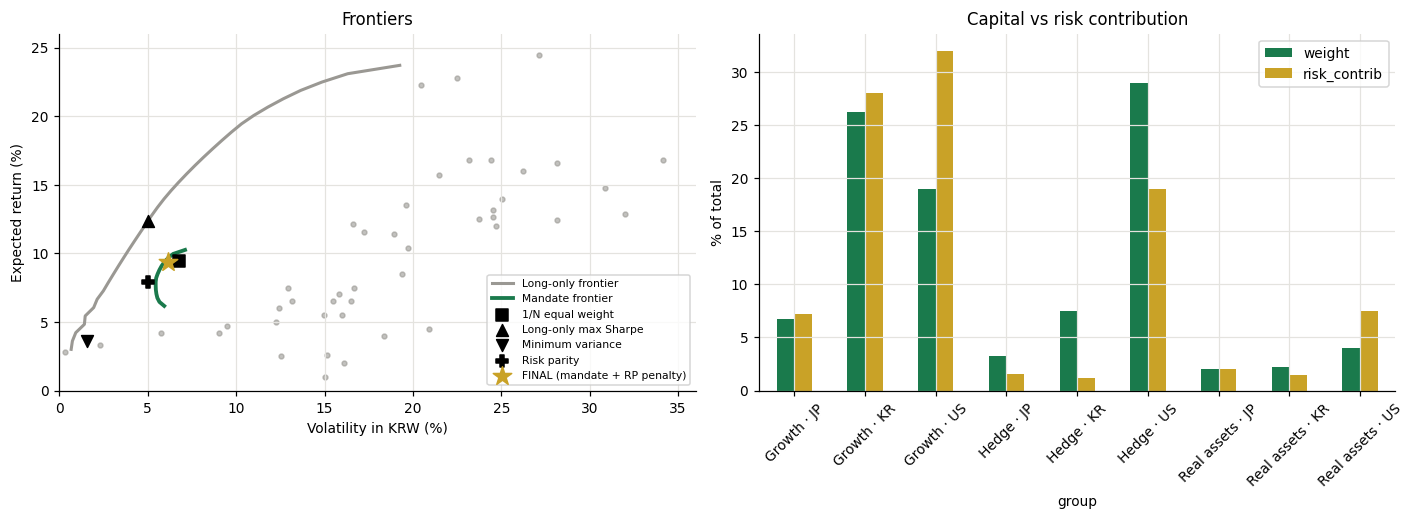

In [15]:
def frontier(cons_, bnds, targets):
    pts = []
    for t in targets:
        r2 = minimize(lambda x: x @ S @ x, w, bounds=bnds,
                      constraints=cons_ + [{"type": "eq", "fun": lambda x, t=t: x @ m - t}],
                      method="SLSQP", options={"maxiter": 3000})
        if r2.success:
            pts.append((np.sqrt(r2.fun), t))
    return np.array(pts)

fr_lo = frontier(budget, [(0, 1)] * N, np.linspace(.03, m.max() * .97, 35))
fr_md = frontier(cons, bounds, np.linspace(.05, .12, 25))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(fr_lo[:, 0] * 100, fr_lo[:, 1] * 100, color=GRAY, lw=2, label="Long-only frontier")
ax[0].plot(fr_md[:, 0] * 100, fr_md[:, 1] * 100, color=GREEN, lw=2.5, label="Mandate frontier")
ax[0].scatter(vol * 100, m * 100, s=10, color=GRAY, alpha=.6)
marks = {"1/N equal weight": "s", "Long-only max Sharpe": "^", "Minimum variance": "v", "Risk parity": "P",
         "FINAL (mandate + RP penalty)": "*"}
for name, mk in marks.items():
    st_ = pstats(methods[name])
    ax[0].scatter(st_["Vol"] * 100, st_["ER"] * 100, marker=mk, s=160 if mk == "*" else 60,
                  color=GOLD if mk == "*" else "k", zorder=5, label=name)
ax[0].set_xlim(0, 36); ax[0].set_ylim(0, 26); ax[0].legend(fontsize=7)
ax[0].set_xlabel("Volatility in KRW (%)"); ax[0].set_ylabel("Expected return (%)"); ax[0].set_title("Frontiers")
g = final.assign(group=final["sleeve"] + " · " + final["country"]).groupby("group")[["weight", "risk_contrib"]].sum()
(g * 100).plot.bar(ax=ax[1], color=[GREEN, GOLD]); ax[1].set_ylabel("% of total")
ax[1].set_title("Capital vs risk contribution"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 7 · Stress tests (KRW base)
Factor shocks anchored to 2008 and 2022, plus overrides where an asset behaves non-linearly. Benchmark: 30% IVV / 30% KODEX 200 / 20% IEF / 20% KODEX KTB10.

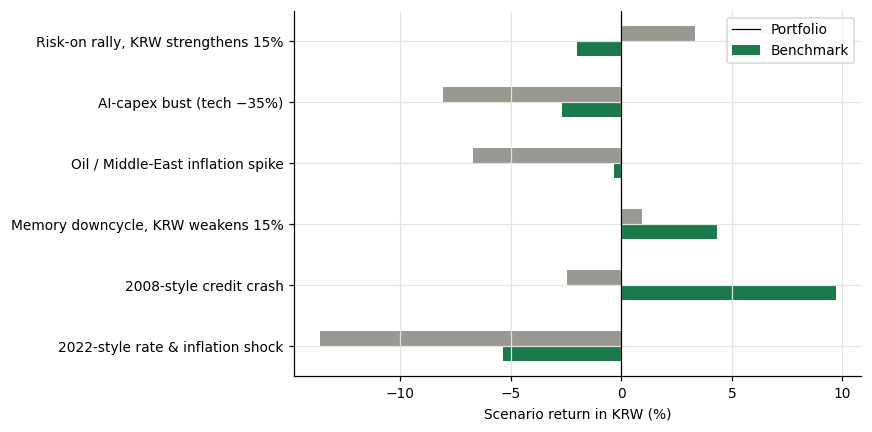

,port,bench
2022-style rate & inflation shock,-5.4%,-13.6%
2008-style credit crash,+9.7%,-2.5%
"Memory downcycle, KRW weakens 15%",+4.3%,+0.9%
Oil / Middle-East inflation spike,-0.3%,-6.7%
AI-capex bust (tech −35%),-2.7%,-8.1%
"Risk-on rally, KRW strengthens 15%",-2.0%,+3.3%


In [16]:
# --------------- factor stress tests (KRW base) ---------------
SC = {
    "2022-style rate & inflation shock": (dict(US_EQ=-.18, KR_EQ=-.06, RATES=-.15, INFL=.20, GOLD=-.01, FX=.06, AUTO=0, JP_EQ=0.0, JPY=-.08, KR_FIN=0),
                                          dict(KMLM=.30, DBMF=.22, TAIL=-.08, BTAL=.16, VTIP=-.03, SGOV=.015, KCD=.02)),
    "2008-style credit crash": (dict(US_EQ=-.37, KR_EQ=-.12, RATES=.18, INFL=-.35, GOLD=.05, FX=.30, AUTO=-.10, JP_EQ=-.10, JPY=.50, KR_FIN=-.10),
                                dict(KMLM=.18, DBMF=.20, TAIL=.15, BTAL=.15, SGOV=.02, KCD=.04)),
    "Memory downcycle, KRW weakens 15%": (dict(US_EQ=-.08, KR_EQ=-.12, RATES=.04, INFL=-.05, GOLD=.05, FX=.15, AUTO=0, JP_EQ=-.03, JPY=.12, KR_FIN=-.05),
                                    dict(SEC_P=-.45, SGOV=.04, KCD=.03)),
    "Oil / Middle-East inflation spike": (dict(US_EQ=-.12, KR_EQ=-.05, RATES=-.08, INFL=.25, GOLD=.20, FX=.08, AUTO=0, JP_EQ=-.05, JPY=.03, KR_FIN=0),
                                          dict(KMLM=.15, DBMF=.15, KEPCO=-.25, SGOV=.04, KCD=.03)),
    "AI-capex bust (tech −35%)": (dict(US_EQ=-.22, KR_EQ=-.08, RATES=.08, INFL=-.08, GOLD=.06, FX=.07, AUTO=0, JP_EQ=-.05, JPY=.08, KR_FIN=0),
                                  dict(SEC_P=-.40, BTAL=.12, SGOV=.04, KCD=.03)),
    "Risk-on rally, KRW strengthens 15%": (dict(US_EQ=.12, KR_EQ=.10, RATES=.04, INFL=.05, GOLD=-.03, FX=-.15, AUTO=.05, JP_EQ=.05, JPY=-.12, KR_FIN=.03),
                                                    dict(KMLM=.02, DBMF=.02, TAIL=-.06, BTAL=-.12, SGOV=.04, KCD=.03)),
}


def scen_ret(fs, ov):
    fvec = np.array([fs[f_] for f_ in F])
    r = B @ fvec
    for k_, v_ in ov.items():                 # override = local return; add FX back for USD assets
        r[ix[k_]] = v_ + (fs["FX"] if country[k_] == "US" else 0) + (fs["JPY"] if country[k_] == "JP" else 0)
    return r


stress = {}
for nm, (fs, ov) in SC.items():
    r = scen_ret(fs, ov)
    stress[nm] = dict(port=float(w @ r), bench=float(wb @ r))

st_df = pd.DataFrame(stress).T
ax = (st_df * 100).plot.barh(color=[GREEN, GRAY], figsize=(8, 4)); ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("Scenario return in KRW (%)"); ax.legend(["Portfolio", "Benchmark"]); plt.tight_layout(); plt.show()
st_df.map("{:+.1%}".format)

The last row is the cost of the hedges: a risk-on rally with a stronger won hurts every USD and JPY asset, so the portfolio lags.

## 8 · Robustness
### 8.1 Penalty strength λ

In [17]:
def opt(lam=.5, mv=m):
    def obj(x):
        rc_ = x * (S @ x); rc_ = rc_ / rc_.sum()
        return -(x @ mv - RF_KRW_CASH) / np.sqrt(x @ S @ x) + lam * N * np.sum((rc_ - rc_.mean()) ** 2)
    x0_ = np.array([np.mean(b_) for b_ in bounds]); x0_ /= x0_.sum()
    return minimize(obj, x0_, bounds=bounds, constraints=cons, method="SLSQP", options={"maxiter": 5000, "ftol": 1e-12})

pd.DataFrame({lam: pstats(opt(lam).x) for lam in [0, .25, .5, 1, 5]}).T.round(3)

,ER,Vol,Sharpe,MaxW,EffN,MaxRC,Hedges
0.0000,0.0970,0.0620,1.1150,0.0680,33.6430,0.0930,0.3880
0.2500,0.0950,0.0610,1.0870,0.0500,37.0680,0.0920,0.3930
0.5000,0.0930,0.0610,1.0680,0.0500,37.1900,0.0910,0.4020
1.0000,0.0920,0.0610,1.0520,0.0500,37.1880,0.0910,0.4090
5.0000,0.0890,0.0610,1.0070,0.0500,37.7210,0.0910,0.4210


### 8.2 Noisy expected returns (200 re-optimisations, μ + N(0, 2pp))
This takes about a minute.

200 draws; average 5–95% band 0.9pp


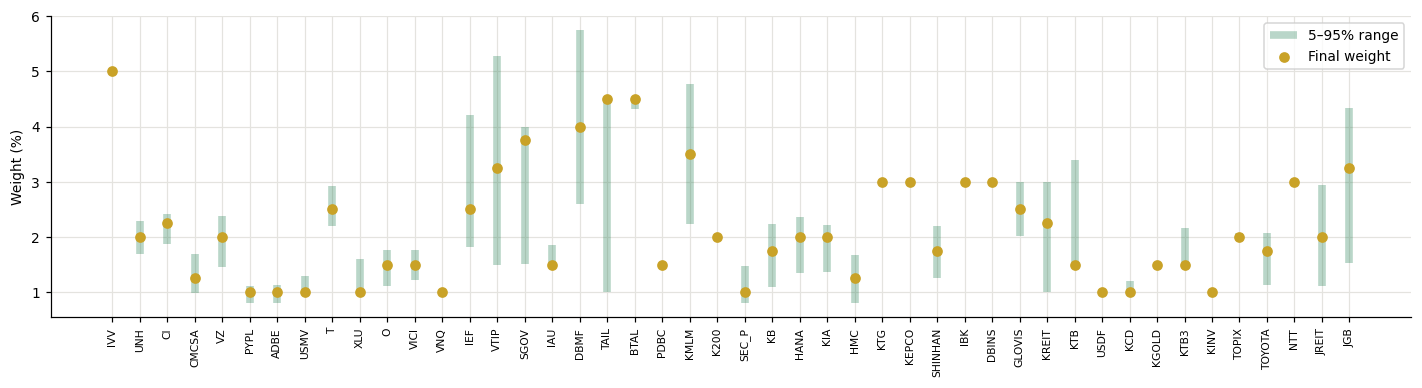

In [18]:
rng = np.random.default_rng(42)
draws = np.array([r_.x for r_ in (opt(mv=m + rng.normal(0, .02, N)) for _ in range(200)) if r_.success])
p5, p95 = np.percentile(draws, 5, 0), np.percentile(draws, 95, 0)
print(f"{len(draws)} draws; average 5–95% band {np.mean(p95 - p5) * 100:.1f}pp")
fig, ax = plt.subplots(figsize=(13, 3.6)); x_ = np.arange(N)
ax.vlines(x_, p5 * 100, p95 * 100, color=GREEN, lw=5, alpha=.3, label="5–95% range")
ax.scatter(x_, w * 100, color=GOLD, zorder=3, label="Final weight")
ax.set_xticks(x_); ax.set_xticklabels(keys, rotation=90, fontsize=7); ax.set_ylabel("Weight (%)"); ax.legend()
plt.tight_layout(); plt.show()

Single-stock weights hardly move because their caps bind. The hedge mix (bond, TIPS, trend and tail funds) moves the most, so read those weights as ranges.

## 9 · Export

In [19]:
final[["ticker", "name", "country", "sleeve", "weight", "exp_ret", "vol", "risk_contrib"]].to_csv("final_weights_46.csv")
print("Saved final_weights_46.csv |", final.groupby("country")["weight"].sum().map("{:.1%}".format).to_dict())

Saved final_weights_46.csv | {'JP': '12.0%', 'KR': '36.0%', 'US': '52.0%'}
